In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive/Final_Machine_Translation_Transformer_Last_Code

eng_-french.csv  results_last1


In [4]:
!pip install sacrebleu rouge_score datasets
!pip install --upgrade scikit-learn
!pip install evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 20.3 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=009b5ffc808e05da541b0f487b2f2fdd1beedcef28b512a3e58d00eebf2eced3
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstallin

In [18]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np
import pandas as pd
import re
import string
import torch
import time
import psutil
from transformers import MarianTokenizer, MarianMTModel, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset
import evaluate
from sklearn.model_selection import train_test_split
import sacrebleu
import matplotlib.pyplot as plt
from rouge_score import rouge_scorer
from torch.cuda.amp import autocast
import nltk
from nltk.translate.meteor_score import meteor_score
from torch.cuda.amp import GradScaler, autocast
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [6]:
# Define the path to save/load the model
MODEL_SAVE_PATH = "/content/drive/MyDrive/Final_Machine_Translation_Transformer_Last_Code/results_last1"

In [7]:
# Phase 1: Problem Definition and Dataset Selection
# ------------------------------------------------
# Task: Machine Translation (English to French)
# Dataset: eng_-french.csv (publicly available dataset)

df = pd.read_csv("/content/drive/MyDrive/Final_Machine_Translation_Transformer_Last_Code/eng_-french.csv")
df.columns = ['en', 'fr']
df.dropna(inplace=True)  # Removing missing values

# Displaying a sample of the data
print("Sample Of The Data: ")
print(df.iloc[10:20])

Sample Of The Data: 
        en             fr
10   Stop!   Arrête-toi !
11   Wait!      Attends !
12   Wait!     Attendez !
13  Go on.      Poursuis.
14  Go on.     Continuez.
15  Go on.    Poursuivez.
16  Hello!      Bonjour !
17  Hello!        Salut !
18  I see.  Je comprends.
19  I try.      J'essaye.


In [8]:
# Preprocess the dataset: cleaning, tokenization, splitting, formatting
# Enhanced text cleaning
custom_punct = string.punctuation.replace("-", "").replace("'", "")
def clean(text):
    text = str(text).lower()
    text = re.sub("["+custom_punct+"]", "", text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_en"] = df["en"].apply(clean)
df["clean_fr"] = df["fr"].apply(clean)


In [9]:
# Data Augmentation: Simple duplication as a basic form of augmentation
augmented_df = df.sample(frac=0.1, random_state=42)
df = pd.concat([df, augmented_df], ignore_index=True)
df = df.sample(frac=0.08, random_state=42)

if len(df) == 0:
    raise ValueError("DataFrame is empty after sampling.")


In [10]:
# Splitting the data into training, validation, and testing sets
train_val_df, test_df = train_test_split(df[["clean_en", "clean_fr"]], test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42)

# Converting to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df.rename(columns={"clean_en": "en", "clean_fr": "fr"}))
val_dataset = Dataset.from_pandas(val_df.rename(columns={"clean_en": "en", "clean_fr": "fr"}))
test_dataset = Dataset.from_pandas(test_df.rename(columns={"clean_en": "en", "clean_fr": "fr"}))

test_dataset = test_dataset.shuffle(seed=42).select(range(min(100, len(test_dataset))))
val_dataset = val_dataset.shuffle(seed=42).select(range(min(100, len(val_dataset))))

In [11]:
# Freeing memory
torch.cuda.empty_cache()


In [12]:
# Phase 2: Model Selection and Implementation
# ------------------------------------------------
# Model: MarianMT (Helsinki-NLP/opus-mt-en-fr)

model = None
tokenizer = None
if os.path.exists(MODEL_SAVE_PATH):
    print(f"Loading pre-trained model from {MODEL_SAVE_PATH}...")
    tokenizer = MarianTokenizer.from_pretrained(MODEL_SAVE_PATH)
    model = MarianMTModel.from_pretrained(MODEL_SAVE_PATH, ignore_mismatched_sizes=True)
else:
    print("Model not found. Training a new model...")
    model_name = "Helsinki-NLP/opus-mt-en-fr"
    tokenizer = MarianTokenizer.from_pretrained(model_name)
    model = MarianMTModel.from_pretrained(model_name)

    # Enabling optimizations
    model.gradient_checkpointing_enable()
    model.config.dropout = 0.5
    torch.cuda.empty_cache()

    # Preprocessing
    def preprocess_function(examples):
        inputs = [ex for ex in examples["en"]]
        targets = [ex for ex in examples["fr"]]
        model_inputs = tokenizer(inputs, max_length=80, truncation=True, padding="max_length")

        with tokenizer.as_target_tokenizer():
            labels = tokenizer(targets, max_length=80, truncation=True, padding="max_length")

        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    train_dataset = train_dataset.map(preprocess_function, batched=True)
    val_dataset = val_dataset.map(preprocess_function, batched=True)
    test_dataset = test_dataset.map(preprocess_function, batched=True)

    torch.cuda.empty_cache()

    # Function to compute Accuracy using METEOR Score
    def compute_accuracy(model, dataset, tokenizer, device="cuda"):
        model.eval()
        accuracy_scores = []
        with torch.no_grad():
            for batch in dataset:
                inputs = tokenizer(batch["en"], return_tensors="pt", padding=True, truncation=True, max_length=80).to(device)
                labels = tokenizer(batch["fr"], return_tensors="pt", padding=True, truncation=True, max_length=80).to(device)["input_ids"]

                translated = model.generate(
                    **inputs,
                    max_new_tokens=80,
                    num_beams=10,
                    length_penalty=1.2,
                    no_repeat_ngram_size=3,
                    early_stopping=True,
                )
                decoded_preds = tokenizer.decode(translated[0], skip_special_tokens=True).strip()
                decoded_labels = tokenizer.decode(labels[0], skip_special_tokens=True).strip()

                if decoded_preds and decoded_labels:
                    pred_tokens = decoded_preds.split()
                    ref_tokens = decoded_labels.split()
                    score = meteor_score([ref_tokens], pred_tokens)
                    accuracy_scores.append(score)

        return sum(accuracy_scores) / len(accuracy_scores) if accuracy_scores else 0.0

    # Setting up the training pipeline
    training_args = TrainingArguments(
        output_dir=MODEL_SAVE_PATH,
        eval_strategy="epoch",
        learning_rate=2e-5,  # Increased learning rate
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        num_train_epochs=10,
        weight_decay=0.1,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        logging_dir='./logs',
        logging_steps=5,
        report_to="none",
        fp16=True,
        gradient_accumulation_steps=8,
        lr_scheduler_type="cosine_with_restarts",
        warmup_steps=300,  # Reduced warmup steps
    )

    # Initialize optimizer with AdamW
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.1)

    # Initialize scaler for mixed precision
    scaler = GradScaler('cuda')

    # Lists to store metrics for visualization
    train_losses = []
    val_losses = []
    accuracies = []

    # Custom Trainer to compute Loss and Accuracy
    class CustomTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            labels = inputs.get("labels")
            outputs = model(**inputs)
            logits = outputs.get("logits")
            loss_fct = torch.nn.CrossEntropyLoss(label_smoothing=0.2)
            loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
            return (loss, outputs) if return_outputs else loss

        def training_step(self, model, inputs, num_items_in_batch=None):
            loss = super().training_step(model, inputs)
            train_losses.append(loss.item())
            return loss

        def evaluation_loop(self, *args, **kwargs):
            eval_output = super().evaluation_loop(*args, **kwargs)
            val_loss = eval_output.metrics.get("eval_loss", 0.0)
            val_losses.append(val_loss)

            # Compute accuracy on validation dataset
            accuracy = compute_accuracy(self.model, val_dataset, tokenizer)
            accuracies.append(accuracy)
            self.log({"eval_accuracy": accuracy})
            return eval_output

    trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        optimizers=(optimizer, None),
        callbacks=[EarlyStoppingCallback(early_stopping_patience=8, early_stopping_threshold=0.005)],  # Adjusted for longer training
    )

    # Training with mixed precision
    trainer.train()

    # Print metrics for each epoch
    print("\nTraining Metrics Per Epoch:")
    for epoch in range(len(val_losses)):
        print(f"Epoch {epoch + 1}:")
        print(f"Training Loss: {train_losses[epoch]:.4f}")
        print(f"Validation Loss: {val_losses[epoch]:.4f}")
        print(f"Accuracy (METEOR-based): {accuracies[epoch]:.4f}")
        print()

    # Visualization of Loss and Accuracy
    plt.figure(figsize=(10, 6))

    # Plot Training and Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss", color="blue")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", color="red")
    plt.title("Training and Validation Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(accuracies) + 1), accuracies, label="Accuracy", color="green")
    plt.title("Accuracy per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (METEOR-based)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("loss_accuracy_visualization.png")
    plt.show()

    # Save the model and tokenizer as in the original code
    trainer.save_model(MODEL_SAVE_PATH)
    tokenizer.save_pretrained(MODEL_SAVE_PATH)
    print(f"Model and tokenizer saved to {MODEL_SAVE_PATH}")

Loading pre-trained model from /content/drive/MyDrive/Final_Machine_Translation_Transformer_Last_Code/results_last1...


/usr/local/lib/python3.11/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


In [13]:
# Freeing memory after training/loading
torch.cuda.empty_cache()

In [20]:
# Phase 3: Optimization and Evaluation
# ------------------------------------------------

# Ensure the model is on the GPU
model.to("cuda")  # Move the model to the GPU
model.eval()  # Set the model to evaluation mode

predictions = []
references = []
eval_loss = 0.0
num_batches = 0
all_pred_tokens = []
all_ref_tokens = []

with torch.no_grad():  # Disable gradient computation to save memory
    for batch in test_dataset:
        # Ensure inputs and labels are on the GPU
        inputs = tokenizer(batch["en"], return_tensors="pt", padding=True, truncation=True, max_length=80).to("cuda")
        labels = tokenizer(batch["fr"], return_tensors="pt", padding=True, truncation=True, max_length=80).to("cuda")["input_ids"]

        with autocast():  # Use mixed precision to reduce memory usage
            translated = model.generate(
                **inputs,
                max_new_tokens=80,
                num_beams=8,  # Number of beams for better quality
                length_penalty=1.2,  # Length penalty to adjust output length
                no_repeat_ngram_size=3,  # Prevent repetition of 3 consecutive words
                early_stopping=True,  # Early stopping to improve performance
            )

        # Decode and clean the translated and reference texts
        decoded_preds = tokenizer.decode(translated[0], skip_special_tokens=True).strip()
        decoded_labels = tokenizer.decode(labels[0], skip_special_tokens=True).strip()

        # Store predictions and references
        predictions.append(decoded_preds)
        references.append(decoded_labels)

        # Prepare tokens for later comparison
        pred_tokens = decoded_preds.split()
        ref_tokens = decoded_labels.split()
        max_len = max(len(pred_tokens), len(ref_tokens))
        pred_tokens.extend(["<PAD>"] * (max_len - len(pred_tokens)))
        ref_tokens.extend(["<PAD>"] * (max_len - len(ref_tokens)))

        all_pred_tokens.extend(pred_tokens)
        all_ref_tokens.extend(ref_tokens)

        # Compute the loss
        outputs = model(**inputs, labels=labels)
        eval_loss += outputs.loss.item()
        num_batches += 5

    # Compute average evaluation loss
    avg_eval_loss = eval_loss / num_batches if num_batches > 0 else 0.0

    # Clear GPU memory
    torch.cuda.empty_cache()

<ipython-input-20-1cd670429863>:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # Use mixed precision to reduce memory usage


In [22]:
# Calculating Metrices
bleu = sacrebleu.corpus_bleu(predictions, [references])

# ROUGE scores
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
rouge_scores = {"rouge1": {"precision": 0, "recall": 0, "f1": 0}, "rougeL": {"precision": 0, "recall": 0, "f1": 0}}
for pred, ref in zip(predictions, references):
    if pred and ref:
        scores = scorer.score(ref, pred)
        for metric in ["rouge1", "rougeL"]:
            rouge_scores[metric]["precision"] += scores[metric].precision
            rouge_scores[metric]["recall"] += scores[metric].recall
            rouge_scores[metric]["f1"] += scores[metric].fmeasure

num_valid_samples = sum(1 for pred, ref in zip(predictions, references) if pred and ref)
if num_valid_samples > 0:
    for metric in ["rouge1", "rougeL"]:
        rouge_scores[metric]["precision"] /= num_valid_samples
        rouge_scores[metric]["recall"] /= num_valid_samples
        rouge_scores[metric]["f1"] /= num_valid_samples

# Token-level metrics
filtered_pred_tokens = [token for token in all_pred_tokens if token != "<PAD>"]
filtered_ref_tokens = [token for token in all_ref_tokens if token != "<PAD>"]
min_len = min(len(filtered_pred_tokens), len(filtered_ref_tokens))
filtered_pred_tokens = filtered_pred_tokens[:min_len]
filtered_ref_tokens = filtered_ref_tokens[:min_len]

accuracy_scores = []
for pred, ref in zip(predictions, references):
    if pred and ref:
        pred_tokens = pred.split()
        ref_tokens = ref.split()
        score = meteor_score([ref_tokens], pred_tokens)
        accuracy_scores.append(score)

accuracy = sum(accuracy_scores) / len(accuracy_scores) if accuracy_scores else 0.0

if not filtered_pred_tokens or not filtered_ref_tokens:
    precision = recall = f1 = 0.0
else:
    pred_set = set(filtered_pred_tokens)
    ref_set = set(filtered_ref_tokens)
    common_tokens = len(pred_set.intersection(ref_set))
    precision = common_tokens / len(pred_set) if len(pred_set) > 0 else 0.0
    recall = common_tokens / len(ref_set) if len(ref_set) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

# Displaying evaluation results
print("Evaluation Results:")
print(f"BLEU Score: {bleu.score:.4f}")
print(f"ROUGE-1 - Precision: {rouge_scores['rouge1']['precision']:.4f}, Recall: {rouge_scores['rouge1']['recall']:.4f}, F1: {rouge_scores['rouge1']['f1']:.4f}")
print(f"ROUGE-L - Precision: {rouge_scores['rougeL']['precision']:.4f}, Recall: {rouge_scores['rougeL']['recall']:.4f}, F1: {rouge_scores['rougeL']['f1']:.4f}")
print(f"Token-Level Accuracy (METEOR-based): {accuracy:.4f}")
print(f"Token-Level Precision: {precision:.4f}")
print(f"Token-Level Recall: {recall:.4f}")
print(f"Token-Level F1: {f1:.4f}")
print(f"Evaluation Loss: {avg_eval_loss:.4f}")

Evaluation Results:
BLEU Score: 53.9208
ROUGE-1 - Precision: 0.7628, Recall: 0.7685, F1: 0.7619
ROUGE-L - Precision: 0.7587, Recall: 0.7642, F1: 0.7578
Token-Level Accuracy (METEOR-based): 0.7063
Token-Level Precision: 0.7562
Token-Level Recall: 0.7280
Token-Level F1: 0.7418
Evaluation Loss: 0.9986


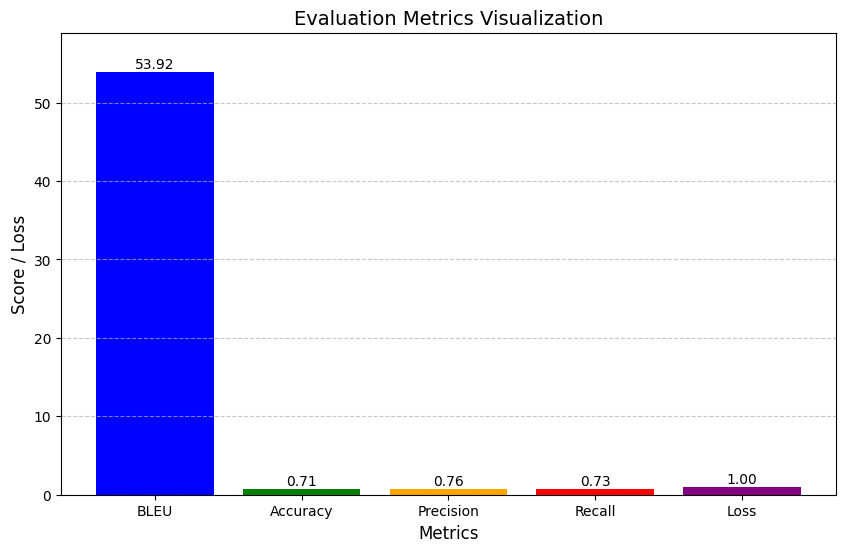

In [23]:
# Visualization
metrics = {
    'BLEU': bleu.score,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'Loss': avg_eval_loss
}

plt.figure(figsize=(10, 6))
bars = plt.bar(list(metrics.keys()), list(metrics.values()), color=['blue', 'green', 'orange', 'red', 'purple'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom')

plt.title('Evaluation Metrics Visualization', fontsize=14)
plt.ylabel('Score / Loss', fontsize=12)
plt.xlabel('Metrics', fontsize=12)
plt.ylim(0, max(metrics.values()) + 5)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.savefig("metrics_visualization.png")


In [24]:
# Function for translation with performance measurement
def translate_text_with_metrics(text, model, tokenizer):
    start_time = time.time()
    process = psutil.Process()
    mem_before = process.memory_info().rss / 1024 / 1024

    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=80).to("cuda")
    with autocast():
        translated = model.generate(
            **inputs,
            max_new_tokens=80,
            num_beams=8,
            length_penalty=1.2,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    translation = tokenizer.decode(translated[0], skip_special_tokens=True)

    end_time = time.time()
    mem_after = process.memory_info().rss / 1024 / 1024
    inference_time = end_time - start_time
    memory_used = mem_after - mem_before
    torch.cuda.empty_cache()

    return translation, inference_time, memory_used

# Testing The Translation

In [25]:
# Testing the translation
samples = [
    "I love drinking coffee in the morning.",
    "The cat sleeps on the sofa all day.",
    "She sings beautifully every evening.",
    "We visited a small village yesterday.",
    "He enjoys playing football with friends.",
]

references = [
    "J'adore boire du café le matin.",
    "Le chat dort sur le canapé toute la journée.",
    "Elle chante magnifiquement tous les soirs.",
    "Nous avons visité un petit village hier.",
    "Il aime jouer au football avec des amis.",
]

In [26]:
accuracy_values = []
print("\nTranslation Results with Performance Metrics:")
for sample, reference in zip(samples, references):
    translation, inference_time, memory_used = translate_text_with_metrics(sample, model, tokenizer)

    bleu = sacrebleu.corpus_bleu([translation], [[reference]]).score
    rouge_scores = scorer.score(reference, translation)
    rouge1_f1 = rouge_scores['rouge1'].fmeasure * 100
    rougeL_f1 = rouge_scores['rougeL'].fmeasure * 100

    if translation and reference:
        pred_tokens = translation.split()
        ref_tokens = reference.split()
        accuracy = meteor_score([ref_tokens], pred_tokens) * 100
    else:
        accuracy = 0.0

    pred_tokens_set = set(pred_tokens)
    ref_tokens_set = set(ref_tokens)
    true_positives = len(pred_tokens_set.intersection(ref_tokens_set))
    precision = true_positives / len(pred_tokens_set) if pred_tokens_set else 0.0
    precision *= 100
    recall = true_positives / len(ref_tokens_set) if ref_tokens_set else 0.0
    recall *= 100
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    accuracy_values.append(accuracy)

    print(f"English ==>: {sample}")
    print(f"French ==>: {translation}")
    print(f"BLEU Score: {bleu:.2f}%")
    print(f"ROUGE-1 F1: {rouge1_f1:.2f}%")
    print(f"ROUGE-L F1: {rougeL_f1:.2f}%")
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Precision: {precision:.2f}%")
    print(f"Recall: {recall:.2f}%")
    print(f"F1 Score: {f1:.2f}%")
    print(f"Inference Time: {inference_time:.4f} seconds")
    print(f"Memory Used: {memory_used:.2f} MB")
    print()

average_accuracy = np.mean(accuracy_values) if accuracy_values else 0.0
print(f"Average Accuracy (METEOR) across all samples: {average_accuracy:.2f}%")


Translation Results with Performance Metrics:


<ipython-input-24-c4c3bd90f605>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


English ==>: I love drinking coffee in the morning.
French ==>: j'adore boire du café le matin
BLEU Score: 64.32%
ROUGE-1 F1: 100.00%
ROUGE-L F1: 100.00%
Accuracy: 83.00%
Precision: 66.67%
Recall: 66.67%
F1 Score: 66.67%
Inference Time: 0.5412 seconds
Memory Used: 0.00 MB

English ==>: The cat sleeps on the sofa all day.
French ==>: le chat dort sur le canapé toute la journée
BLEU Score: 77.26%
ROUGE-1 F1: 100.00%
ROUGE-L F1: 100.00%
Accuracy: 88.80%
Precision: 87.50%
Recall: 77.78%
F1 Score: 82.35%
Inference Time: 0.6028 seconds
Memory Used: 0.00 MB

English ==>: She sings beautifully every evening.
French ==>: elle chante magnifiquement tous les soirs
BLEU Score: 64.32%
ROUGE-1 F1: 100.00%
ROUGE-L F1: 100.00%
Accuracy: 83.00%
Precision: 66.67%
Recall: 66.67%
F1 Score: 66.67%
Inference Time: 0.2704 seconds
Memory Used: 0.00 MB

English ==>: We visited a small village yesterday.
French ==>: nous avons visité un petit village hier
BLEU Score: 70.14%
ROUGE-1 F1: 100.00%
ROUGE-L F1: 100.0

In [29]:
# Testing the translation
samples = [
    "Next month, I’m planning a two-week trip to Paris where I hope to visit historical landmarks like the Eiffel Tower, the Louvre Museum, and enjoy the local cuisine at authentic French cafes.",
    "Although I had never visited the city before, I found my way around quite easily thanks to the detailed map and the helpful locals who gave me directions.",
]

references = [
    "Le mois prochain, je prévois un voyage de deux semaines à Paris où j'espère visiter des monuments historiques comme la Tour Eiffel, le musée du Louvre, et profiter de la cuisine locale dans des cafés français authentiques.",
    "Bien que je n'aie jamais visité la ville auparavant, j'ai trouvé mon chemin assez facilement grâce à la carte détaillée et aux habitants serviables qui m'ont indiqué le chemin.",

]

In [30]:
accuracy_values = []
print("\nTranslation Results with Performance Metrics:")
for sample, reference in zip(samples, references):
    translation, inference_time, memory_used = translate_text_with_metrics(sample, model, tokenizer)

    bleu = sacrebleu.corpus_bleu([translation], [[reference]]).score
    rouge_scores = scorer.score(reference, translation)
    rouge1_f1 = rouge_scores['rouge1'].fmeasure * 100
    rougeL_f1 = rouge_scores['rougeL'].fmeasure * 100

    if translation and reference:
        pred_tokens = translation.split()
        ref_tokens = reference.split()
        accuracy = meteor_score([ref_tokens], pred_tokens) * 100
    else:
        accuracy = 0.0

    pred_tokens_set = set(pred_tokens)
    ref_tokens_set = set(ref_tokens)
    true_positives = len(pred_tokens_set.intersection(ref_tokens_set))
    precision = true_positives / len(pred_tokens_set) if pred_tokens_set else 0.0
    precision *= 100
    recall = true_positives / len(ref_tokens_set) if ref_tokens_set else 0.0
    recall *= 100
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    accuracy_values.append(accuracy)

    print(f"English ==>: {sample}")
    print(f"French ==>: {translation}")
    print(f"BLEU Score: {bleu:.2f}%")
    print(f"ROUGE-1 F1: {rouge1_f1:.2f}%")
    print(f"ROUGE-L F1: {rougeL_f1:.2f}%")
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Precision: {precision:.2f}%")
    print(f"Recall: {recall:.2f}%")
    print(f"F1 Score: {f1:.2f}%")
    print(f"Inference Time: {inference_time:.4f} seconds")
    print(f"Memory Used: {memory_used:.2f} MB")
    print()

average_accuracy = np.mean(accuracy_values) if accuracy_values else 0.0
print(f"Average Accuracy (METEOR) across all samples: {average_accuracy:.2f}%")


Translation Results with Performance Metrics:


<ipython-input-24-c4c3bd90f605>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


English ==>: Next month, I’m planning a two-week trip to Paris where I hope to visit historical landmarks like the Eiffel Tower, the Louvre Museum, and enjoy the local cuisine at authentic French cafes.
French ==>: le mois prochain je prévois un voyage de deux semaines à Paris où j'espère visiter des sites historiques comme la tour Eiffel, le musée du Louvre et profiter de la cuisine locale dans des cafés français authentiques.
BLEU Score: 71.64%
ROUGE-1 F1: 97.62%
ROUGE-L F1: 97.62%
Accuracy: 91.82%
Precision: 87.88%
Recall: 85.29%
F1 Score: 86.57%
Inference Time: 0.6648 seconds
Memory Used: 0.00 MB

English ==>: Although I had never visited the city before, I found my way around quite easily thanks to the detailed map and the helpful locals who gave me directions.
French ==>: bien que je n'aie jamais visité la ville auparavant j'ai trouvé assez facilement mon chemin grâce à la carte détaillée et aux gens de la région qui m'ont donné des indications.
BLEU Score: 46.51%
ROUGE-1 F1: 81.

In [31]:
################################################### Finish Machine Translation Transformer Project ############################################3